# 01 — Data Exploration

Inspect the raw landscape CSV: class balance, enrichment distributions,
mutation count histograms, and sequence diversity across sublibraries.
Run this before training to verify the preprocessing pipeline output.

In [ ]:
#troubleshooting the kernel
import sys; print(sys.executable)

## to create the environment:
# # 1. create the env
# conda create -n nucb_env python=3.11 -y

# # 2. activate it
# conda activate nucb_env

# # 3. install the repo and all dependencies
# pip install -e ".[dev]"


/Users/zahmiriajohnson/opt/miniconda3/envs/nucb_env/bin/python


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from nucb_transformer.data.dataset import load_landscape
from nucb_transformer.data.splits import mutation_count_split

In [27]:
import matplotlib.patches as mpatches

In [3]:
df = load_landscape()
train_df, val_df, test_df = mutation_count_split(df)

train_pool = df[df["num_mutations"] <= 2]  # train + val together

print(f"Train pool (\u22642 mut): {len(train_pool):,}  |  Test (>2 mut): {len(test_df):,}  |  Total: {len(df):,}")

Train pool (≤2 mut): 13,066  |  Test (>2 mut): 42,694  |  Total: 55,760


In [31]:
CLASS_COLORS = {
    "non-functional":  "#4a8fbf",
    "activity > 0":    "#dcdcaa",
    "activity > WT":   "#6a9955",
    "activity > A73R": "#4ec9b0",
}

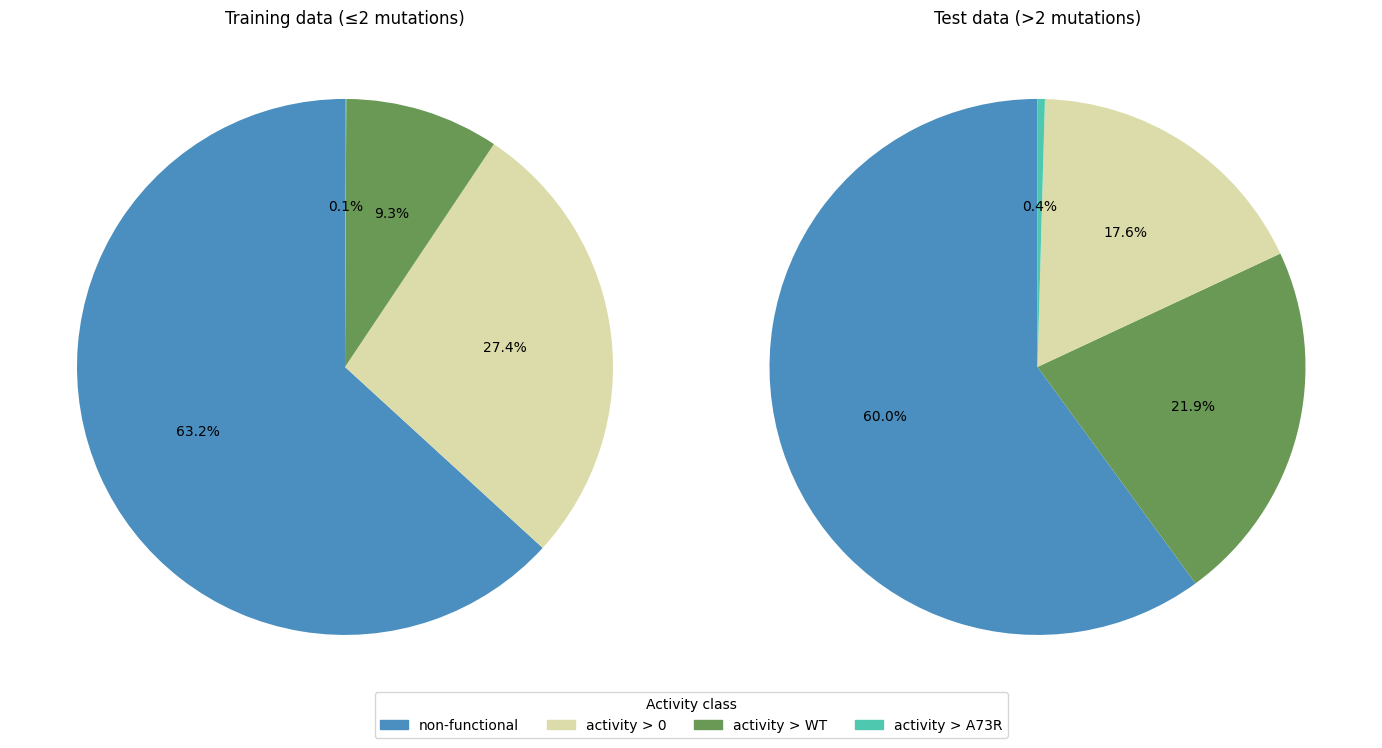

In [32]:
# Pies
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Pie 1: training data (<=2 mutations)
counts = train_pool["activity_level"].value_counts()
ax[0].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
ax[0].set_title("Training data (\u22642 mutations)")

# Pie 2: test data (>2 mutations)
counts = test_df["activity_level"].value_counts()

ax[1].pie(
    counts,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
ax[1].set_title("Test data (>2 mutations)")

handles = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
fig.legend(handles=handles, title="Activity class", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))


plt.tight_layout()
plt.show()


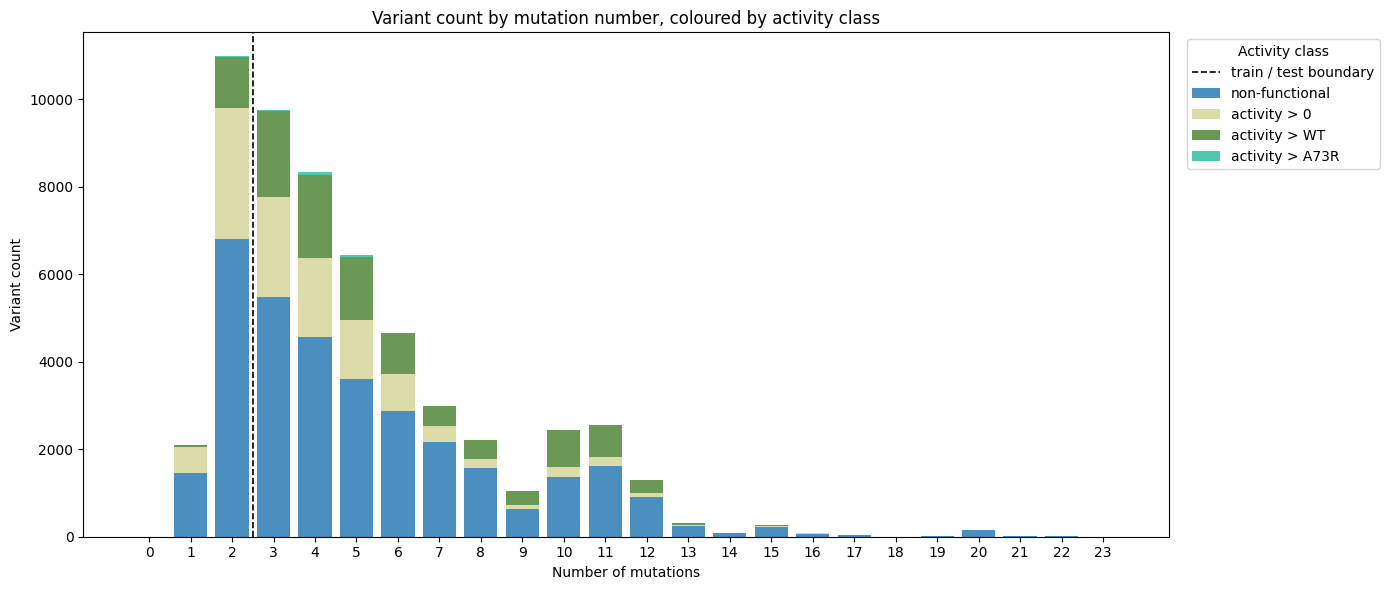

In [33]:
# Stacked bar: variant count by mutation number, coloured by activity class
class_order = ["non-functional", "activity > 0", "activity > WT", "activity > A73R"]

pivot = (
    df.groupby(["num_mutations", "activity_level"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot[[c for c in class_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = pd.Series(0, index=pivot.index)
for cls in pivot.columns:
    ax.bar(pivot.index, pivot[cls], bottom=bottom, label=cls, color=CLASS_COLORS[cls])
    bottom = bottom + pivot[cls]

ax.axvline(x=2.5, color="black", linestyle="--", linewidth=1.2, label="train / test boundary")
ax.set_xlabel("Number of mutations")
ax.set_ylabel("Variant count")
ax.set_title("Variant count by mutation number, coloured by activity class")
ax.set_xticks(pivot.index)
ax.legend(title="Activity class", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()